In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
policy_df = pd.read_csv('../data/insurance_policyholder_churn_synthetic.csv')

policy_df.head()
policy_df.shape
policy_df.columns
policy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_p

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1) 목표/피처 선택
features = [
    'age', 'customer_tenure_months', 'premium_change_pct',
    'quote_requested_flag', 'autopay_enabled',
    'late_payment_count_12m', 'missed_payment_flag',
    'coverage_downgrade_flag'
]
target = 'churn_flag'

X = policy_df[features].copy()
y = policy_df[target].copy()

# (선택) 혹시 0/1이 문자열로 들어간 경우 대비 → 숫자로 강제
X = X.apply(pd.to_numeric, errors='coerce')

# 2) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) 전처리
numeric_features = features
categorical_features = []

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 4) 모델
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# 5) 학습
model.fit(X_train, y_train)

# 6) threshold 적용 예측
threshold = 0.45  # 너가 스캔 결과로 선택한 값
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

# 7) 평가
print(f"Threshold = {threshold}")
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Threshold = 0.45
              precision    recall  f1-score   support

           0       0.82      0.57      0.67      6983
           1       0.42      0.72      0.53      3017

    accuracy                           0.61     10000
   macro avg       0.62      0.64      0.60     10000
weighted avg       0.70      0.61      0.63     10000

Confusion matrix:
 [[3982 3001]
 [ 853 2164]]


In [7]:
from sklearn.metrics import precision_recall_fscore_support

y_prob = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.2, 0.81, 0.05)
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_t, average=None)
    # class 1 기준
    print(f"t={t:.2f} | P1={p[1]:.2f} R1={r[1]:.2f} F1_1={f1[1]:.2f}")

t=0.20 | P1=0.31 R1=0.99 F1_1=0.47
t=0.25 | P1=0.32 R1=0.97 F1_1=0.48
t=0.30 | P1=0.34 R1=0.93 F1_1=0.49
t=0.35 | P1=0.36 R1=0.88 F1_1=0.51
t=0.40 | P1=0.39 R1=0.80 F1_1=0.52
t=0.45 | P1=0.42 R1=0.72 F1_1=0.53
t=0.50 | P1=0.46 R1=0.63 F1_1=0.53
t=0.55 | P1=0.49 R1=0.53 F1_1=0.51
t=0.60 | P1=0.54 R1=0.43 F1_1=0.48
t=0.65 | P1=0.58 R1=0.33 F1_1=0.42
t=0.70 | P1=0.63 R1=0.23 F1_1=0.34
t=0.75 | P1=0.70 R1=0.16 F1_1=0.26
t=0.80 | P1=0.75 R1=0.09 F1_1=0.16


다양한 임계값(threshold)에 대해 Precision, Recall, F1-score를 비교한 결과 0.45에서 가장 균형 잡힌 성능(F1=0.53)을 보였다. 해당 임계값에서는 이탈 고객에 대한 Recall이 0.72로 나타나 실제 이탈 고객의 약 72%를 탐지할 수 있었다.

<Axes: >

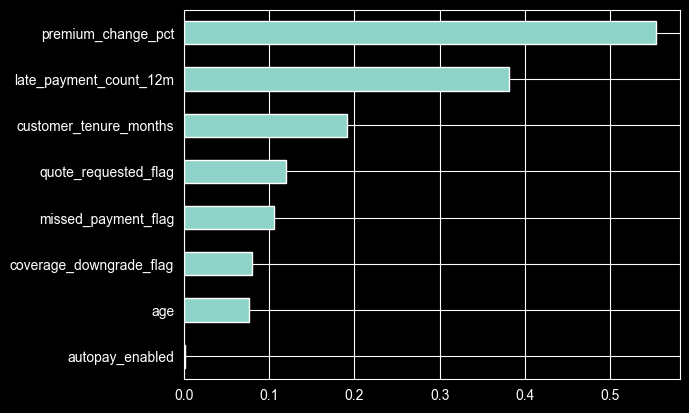

In [8]:
importance = pd.Series(
    abs(model.named_steps["clf"].coef_[0]),
    index=features
)

importance.sort_values().plot(kind="barh")

Feature importance 분석 결과 보험료 상승률(premium_change_pct)이 고객 이탈에 가장 큰 영향을 미치는 변수로 나타났으며, 연체 횟수(late_payment_count_12m)와 가입 기간(customer_tenure_months) 역시 주요 이탈 요인으로 확인되었다.

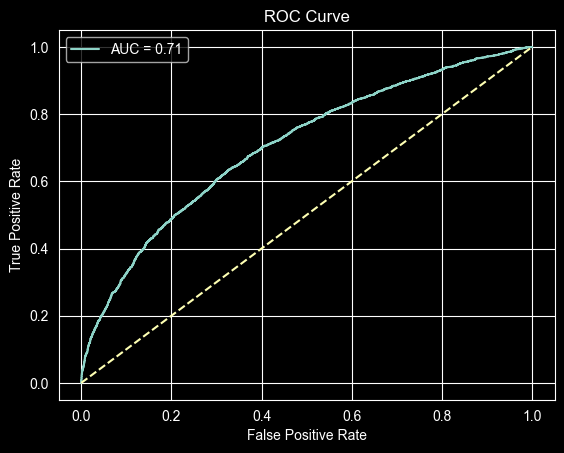

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ROC Curve 분석 결과 모델의 AUC 값은 0.71로 나타났으며, 이는 모델이 고객 이탈 여부를 무작위 예측보다 유의미하게 구분할 수 있음을 의미한다. ROC 곡선이 기준선보다 위쪽에 위치하여 모델이 일정 수준 이상의 예측 성능을 보이는 것으로 확인되었다.